# HW02 - 多层感知机、正则化、数值稳定性与协变量偏移

> 姓名：付航  
> 学号：20234080304  


## 1. 多层感知机

### 1.1 理论计算题

#### 题 1：非线性激活函数的重要性

给定单隐藏层 MLP：

$$
 h = W_1x + b_1
$$

$$
 o = W_2h + b_2
$$

将隐藏层表达式代入输出层：

$$
\begin{aligned}
o &= W_2(W_1x+b_1)+b_2\\
  &= W_2W_1x + W_2b_1 + b_2
\end{aligned}
$$

令：

$$
W' = W_2W_1
$$

$$
b' = W_2b_1 + b_2
$$

则：

$$
o = W'x + b'
$$

因此，如果隐藏层没有非线性激活函数，多个线性层的复合仍然只是一个线性变换，该网络等价于一个单层神经网络。由此可见，非线性激活函数是多层神经网络获得非线性表达能力的关键。

#### 题 2：Sigmoid 与 tanh 的表达式及导数

Sigmoid 函数：

$$
\sigma(x)=\frac{1}{1+e^{-x}}
$$

其导数为：

$$
\sigma'(x)=\sigma(x)(1-\sigma(x))
$$

推导：

$$
\begin{aligned}
\sigma'(x) &= \left(1+e^{-x}\right)^{-1}{}'\\
&= \frac{e^{-x}}{(1+e^{-x})^2}\\
&= \frac{1}{1+e^{-x}}\left(1-\frac{1}{1+e^{-x}}\right)\\
&= \sigma(x)(1-\sigma(x))
\end{aligned}
$$

tanh 函数：

$$
\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}
$$

其导数为：

$$
\tanh'(x)=1-\tanh^2(x)
$$

这说明两者的导数都可以用函数自身表示，便于反向传播计算。

### 1.2 编程题：从零实现 Fashion-MNIST 单隐藏层 MLP

In [1]:
import math
import random
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# 为保证实验可复现
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

print('PyTorch version:', torch.__version__)

PyTorch version: 2.10.0+cpu


In [2]:
# 读取 Fashion-MNIST 数据集。
# 说明：这里仅使用 torchvision 负责数据下载和读取，不使用深度学习框架的高级模型 API。
# 如果当前环境不能联网下载，代码会自动退化为 sklearn digits 数据集，保证 Notebook 可运行。

def load_fashion_mnist_or_fallback(batch_size=256, small_train=None):
    try:
        from torchvision import datasets, transforms
        transform = transforms.Compose([transforms.ToTensor()])
        train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
        test_set = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
        X_train = train_set.data.float().reshape(-1, 784) / 255.0
        y_train = train_set.targets.long()
        X_test = test_set.data.float().reshape(-1, 784) / 255.0
        y_test = test_set.targets.long()
        dataset_name = 'Fashion-MNIST'
    except Exception as e:
        print('Fashion-MNIST 暂时无法读取，使用 sklearn digits 作为可运行备用数据。原因：', repr(e))
        from sklearn.datasets import load_digits
        from sklearn.model_selection import train_test_split
        digits = load_digits()
        X = torch.tensor(digits.data, dtype=torch.float32) / 16.0
        y = torch.tensor(digits.target, dtype=torch.long)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=seed, stratify=y.numpy()
        )
        dataset_name = 'sklearn digits fallback'

    if small_train is not None:
        X_train = X_train[:small_train]
        y_train = y_train[:small_train]

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)
    return train_loader, test_loader, X_train.shape[1], int(y_train.max().item() + 1), dataset_name

train_loader, test_loader, num_inputs, num_outputs, dataset_name = load_fashion_mnist_or_fallback(batch_size=256)
print('使用数据集:', dataset_name)
print('输入维度:', num_inputs, '类别数:', num_outputs)

Fashion-MNIST 暂时无法读取，使用 sklearn digits 作为可运行备用数据。原因： ModuleNotFoundError("No module named 'torchvision'")
使用数据集: sklearn digits fallback
输入维度: 64 类别数: 10


In [3]:
# 手动初始化参数
num_hiddens = 256

def init_params(num_inputs, num_hiddens, num_outputs):
    W1 = torch.randn(num_inputs, num_hiddens) * 0.01
    b1 = torch.zeros(num_hiddens)
    W2 = torch.randn(num_hiddens, num_outputs) * 0.01
    b2 = torch.zeros(num_outputs)
    params = [W1, b1, W2, b2]
    for p in params:
        p.requires_grad_(True)
    return params

def relu(X):
    return torch.maximum(X, torch.zeros_like(X))

def net(X, params, dropout=0.0, is_training=False):
    W1, b1, W2, b2 = params
    H = relu(torch.matmul(X, W1) + b1)
    if dropout > 0:
        H = dropout_layer(H, dropout, is_training=is_training)
    return torch.matmul(H, W2) + b2

def softmax_cross_entropy(logits, y):
    # 数值稳定版本：log_softmax = logits - logsumexp(logits)
    shifted_logits = logits - logits.max(dim=1, keepdim=True).values
    log_probs = shifted_logits - torch.log(torch.exp(shifted_logits).sum(dim=1, keepdim=True))
    return -log_probs[torch.arange(y.shape[0]), y].mean()

def accuracy(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def evaluate(loader, params):
    total_loss, total_acc, total_n = 0.0, 0.0, 0
    with torch.no_grad():
        for X, y in loader:
            logits = net(X, params, dropout=0.0, is_training=False)
            loss = softmax_cross_entropy(logits, y)
            n = y.shape[0]
            total_loss += loss.item() * n
            total_acc += accuracy(logits, y) * n
            total_n += n
    return total_loss / total_n, total_acc / total_n

def sgd(params, lr, batch_size, weight_decay=0.0):
    with torch.no_grad():
        for p in params:
            if p.grad is None:
                continue
            # 权重衰减只建议作用在矩阵权重上，不作用在偏置上
            if weight_decay > 0 and p.ndim > 1:
                p *= (1 - lr * weight_decay)
            p -= lr * p.grad
            p.grad.zero_()

print('基础函数定义完成。')

基础函数定义完成。


In [4]:
def train_mlp(train_loader, test_loader, num_inputs, num_hiddens, num_outputs,
              epochs=5, lr=0.1, weight_decay=0.0, dropout=0.0):
    params = init_params(num_inputs, num_hiddens, num_outputs)
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        train_loss_sum, train_acc_sum, train_n = 0.0, 0.0, 0
        for X, y in train_loader:
            logits = net(X, params, dropout=dropout, is_training=True)
            loss = softmax_cross_entropy(logits, y)
            loss.backward()
            sgd(params, lr, X.shape[0], weight_decay=weight_decay)
            n = y.shape[0]
            train_loss_sum += loss.item() * n
            train_acc_sum += accuracy(logits.detach(), y) * n
            train_n += n

        train_loss = train_loss_sum / train_n
        train_acc = train_acc_sum / train_n
        test_loss, test_acc = evaluate(test_loader, params)
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        print(f'Epoch {epoch+1:02d}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, test_loss={test_loss:.4f}, test_acc={test_acc:.4f}')
    return params, history

params_basic, history_basic = train_mlp(
    train_loader, test_loader, num_inputs, num_hiddens, num_outputs,
    epochs=5, lr=0.5, weight_decay=0.0, dropout=0.0
)

Epoch 01: train_loss=2.2978, train_acc=0.1858, test_loss=2.2863, test_acc=0.5583
Epoch 02: train_loss=2.2751, train_acc=0.5198, test_loss=2.2488, test_acc=0.6917
Epoch 03: train_loss=2.2196, train_acc=0.7063, test_loss=2.1521, test_acc=0.6889
Epoch 04: train_loss=2.0775, train_acc=0.7056, test_loss=1.9283, test_acc=0.7028
Epoch 05: train_loss=1.7924, train_acc=0.7168, test_loss=1.5639, test_acc=0.6778


## 2. 模型选择、权重衰减和丢弃法

### 2.1 理论计算题

#### 题 1：过拟合与欠拟合

训练误差是模型在训练集上的误差，反映模型对已见样本的拟合能力；泛化误差是模型在未见测试数据或真实分布上的期望误差，反映模型对新样本的预测能力。

当训练误差极低但泛化误差很高时，模型处于过拟合状态。模型记住了训练样本中的噪声或偶然模式，但没有学到稳定的一般规律。

缓解过拟合可通过控制模型复杂度实现，例如：减少参数数量、减少网络层数或隐藏单元数量、加入 L2 正则化、使用 Dropout、早停法、增加训练数据或数据增强。欠拟合则通常表现为训练误差和泛化误差都较高，需要提高模型复杂度、增加训练轮数或改善特征表示。

#### 题 2：K 折交叉验证算法步骤

K 折交叉验证的步骤如下：

1. 将原始训练数据随机划分为 K 个大小尽量相等的互斥子集。
2. 对第 k 次实验，取第 k 个子集作为验证集，其余 K-1 个子集合并作为训练集。
3. 在训练集上训练模型，在验证集上计算验证误差。
4. 重复 K 次，使每个子集都恰好作为一次验证集。
5. 将 K 次验证误差取平均，作为当前模型或超参数组合的性能估计。
6. 选择平均验证误差最小的模型或超参数，再用全部训练数据重新训练最终模型。

### 2.2 编程题：加入 L2 正则化和 Dropout

In [5]:
def dropout_layer(X, dropout, is_training=True):
    """从零实现 Dropout。测试阶段不触发 Dropout。"""
    if not is_training or dropout == 0:
        return X
    if dropout == 1:
        return torch.zeros_like(X)
    mask = (torch.rand(X.shape, device=X.device) > dropout).float()
    return mask * X / (1.0 - dropout)

# 简单测试 dropout_layer
X_demo = torch.ones(10)
print('Dropout 输入:', X_demo.numpy())
print('训练阶段 dropout=0.5 输出:', dropout_layer(X_demo, 0.5, True).numpy())
print('测试阶段 dropout=0.5 输出:', dropout_layer(X_demo, 0.5, False).numpy())

Dropout 输入: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
训练阶段 dropout=0.5 输出: [2. 2. 2. 2. 0. 0. 0. 2. 0. 2.]
测试阶段 dropout=0.5 输出: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [6]:
# 为了更明显地观察过拟合与正则化效果，这里使用极少样本训练较复杂 MLP。
small_train_loader, val_loader, num_inputs2, num_outputs2, dataset_name2 = load_fashion_mnist_or_fallback(
    batch_size=64, small_train=600
)
print('正则化对比实验数据集:', dataset_name2)
print('小训练集输入维度:', num_inputs2, '类别数:', num_outputs2)

histories = {}
configs = {
    '无正则化': {'weight_decay': 0.0, 'dropout': 0.0},
    '权重衰减': {'weight_decay': 1e-3, 'dropout': 0.0},
    'Dropout': {'weight_decay': 0.0, 'dropout': 0.5},
}

for name, cfg in configs.items():
    print('\n实验:', name)
    _, hist = train_mlp(
        small_train_loader, val_loader, num_inputs2, 512, num_outputs2,
        epochs=15, lr=0.3, weight_decay=cfg['weight_decay'], dropout=cfg['dropout']
    )
    histories[name] = hist

Fashion-MNIST 暂时无法读取，使用 sklearn digits 作为可运行备用数据。原因： ModuleNotFoundError("No module named 'torchvision'")
正则化对比实验数据集: sklearn digits fallback
小训练集输入维度: 64 类别数: 10

实验: 无正则化
Epoch 01: train_loss=2.2911, train_acc=0.1967, test_loss=2.2704, test_acc=0.3417
Epoch 02: train_loss=2.2361, train_acc=0.4200, test_loss=2.1912, test_acc=0.3361
Epoch 03: train_loss=2.0965, train_acc=0.4017, test_loss=1.9857, test_acc=0.4667
Epoch 04: train_loss=1.8008, train_acc=0.5400, test_loss=1.6493, test_acc=0.4556
Epoch 05: train_loss=1.4106, train_acc=0.6450, test_loss=1.3675, test_acc=0.4972
Epoch 06: train_loss=1.0702, train_acc=0.7567, test_loss=1.0089, test_acc=0.7361
Epoch 07: train_loss=0.8242, train_acc=0.8217, test_loss=0.8032, test_acc=0.7750
Epoch 08: train_loss=0.6522, train_acc=0.8617, test_loss=0.7176, test_acc=0.8139
Epoch 09: train_loss=0.5391, train_acc=0.8850, test_loss=0.5704, test_acc=0.8500
Epoch 10: train_loss=0.4599, train_acc=0.9033, test_loss=0.5029, test_acc=0.8861
Epoch 11: train_l

f:\anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21017 (\N{CJK UNIFIED IDEOGRAPH-5219}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12289 (\N{IDEOGRAPHIC COMMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\anconda\Lib\site-packages\IPyth

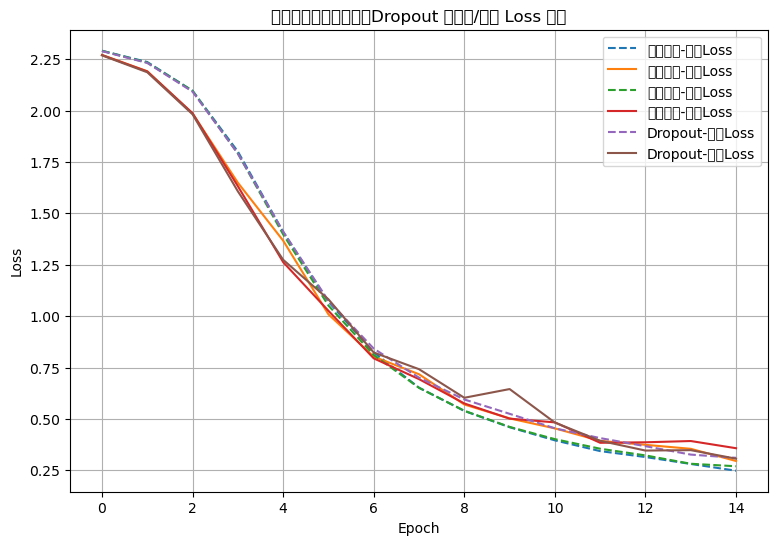

In [7]:
plt.figure(figsize=(9, 6))
for name, hist in histories.items():
    plt.plot(hist['train_loss'], linestyle='--', label=f'{name}-训练Loss')
    plt.plot(hist['test_loss'], label=f'{name}-验证Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('无正则化、权重衰减、Dropout 的训练/验证 Loss 曲线')
plt.legend()
plt.grid(True)
plt.show()

## 3. 数值稳定性和激活函数

### 3.1 理论计算题

深层网络反向传播中的梯度常包含矩阵连乘项：

$$
\prod_{i=t}^{d-1}\frac{\partial h^{i+1}}{\partial h^i}
$$

设每一层局部雅可比矩阵为 $J_i$。若用谱范数衡量其放大能力，则有：

$$
\left\|\prod_i J_i\right\| \le \prod_i \|J_i\|
$$

如果多数层满足 $\|J_i\|>1$，则连乘结果会随层数指数级增大，产生梯度爆炸；如果多数层满足 $\|J_i\|<1$，则连乘结果会随层数指数级减小，产生梯度消失。

从激活函数角度看，Sigmoid 的导数最大值为 0.25，tanh 的导数最大值为 1，但在饱和区间接近 0。因此深层网络中反复乘以小于 1 的导数，容易导致梯度消失。若权重矩阵的奇异值很大，矩阵连乘可能迅速放大梯度，导致梯度爆炸。

ReLU 的表达式为：

$$
\operatorname{ReLU}(x)=\max(0,x)
$$

其导数在 $x>0$ 时为 1，在 $x<0$ 时为 0。对于正激活区域，梯度可以近似无衰减地传播，因此 ReLU 能在很大程度上缓解 Sigmoid/tanh 饱和区导致的梯度消失问题。但 ReLU 仍可能出现“神经元死亡”或在权重过大时产生梯度爆炸，因此仍需要合适的初始化策略。

### 3.2 编程题：模拟数值不稳定并验证初始化策略

In [8]:
import torch.nn as nn

def build_deep_net(activation='sigmoid', init='normal1', depth=20, width=256, input_dim=256, output_dim=10):
    layers = []
    in_dim = input_dim
    for _ in range(depth):
        linear = nn.Linear(in_dim, width)
        if init == 'normal1':
            nn.init.normal_(linear.weight, mean=0.0, std=1.0)
        elif init == 'normal10':
            nn.init.normal_(linear.weight, mean=0.0, std=10.0)
        elif init == 'xavier':
            nn.init.xavier_uniform_(linear.weight)
        nn.init.zeros_(linear.bias)
        layers.append(linear)
        if activation == 'sigmoid':
            layers.append(nn.Sigmoid())
        elif activation == 'relu':
            layers.append(nn.ReLU())
        elif activation == 'leaky_relu':
            layers.append(nn.LeakyReLU(0.01))
        in_dim = width
    out = nn.Linear(width, output_dim)
    nn.init.xavier_uniform_(out.weight)
    nn.init.zeros_(out.bias)
    layers.append(out)
    return nn.Sequential(*layers)

def print_gradient_norms(model, title):
    print('\n' + title)
    norms = []
    for i, layer in enumerate(model):
        if isinstance(layer, nn.Linear) and layer.weight.grad is not None:
            norm = layer.weight.grad.norm().item()
            norms.append(norm)
    for i, norm in enumerate(norms[:3]):
        print(f'前部第 {i+1} 个线性层梯度范数: {norm:.6e}')
    for i, norm in enumerate(norms[-3:]):
        print(f'后部第 {len(norms)-2+i} 个线性层梯度范数: {norm:.6e}')
    print('是否存在 NaN:', any(torch.isnan(p.grad).any().item() for p in model.parameters() if p.grad is not None))
    print('梯度范数最小值:', f'{min(norms):.6e}', '最大值:', f'{max(norms):.6e}')
    return norms

def run_gradient_experiment(activation, init, title):
    torch.manual_seed(seed)
    model = build_deep_net(activation=activation, init=init)
    X = torch.randn(64, 256)
    y = torch.randint(0, 10, (64,))
    criterion = nn.CrossEntropyLoss()
    logits = model(X)
    loss = criterion(logits, y)
    loss.backward()
    norms = print_gradient_norms(model, title + f'，loss={loss.item():.4f}')
    return norms

norms_sigmoid = run_gradient_experiment('sigmoid', 'normal1', 'Sigmoid + 普通高斯初始化 std=1')
norms_relu_big = run_gradient_experiment('relu', 'normal10', 'ReLU + 过大初始化 std=10')
norms_xavier = run_gradient_experiment('leaky_relu', 'xavier', 'LeakyReLU + Xavier 初始化')


Sigmoid + 普通高斯初始化 std=1，loss=2.4770
前部第 1 个线性层梯度范数: 9.349315e+00
前部第 2 个线性层梯度范数: 6.514073e+00
前部第 3 个线性层梯度范数: 5.698215e+00
后部第 19 个线性层梯度范数: 2.151949e-01
后部第 20 个线性层梯度范数: 2.276050e-01
后部第 21 个线性层梯度范数: 2.273865e+00
是否存在 NaN: False
梯度范数最小值: 2.151949e-01 最大值: 9.349315e+00

ReLU + 过大初始化 std=10，loss=nan
前部第 1 个线性层梯度范数: nan
前部第 2 个线性层梯度范数: nan
前部第 3 个线性层梯度范数: nan
后部第 19 个线性层梯度范数: nan
后部第 20 个线性层梯度范数: nan
后部第 21 个线性层梯度范数: nan
是否存在 NaN: True
梯度范数最小值: nan 最大值: nan

LeakyReLU + Xavier 初始化，loss=2.3025
前部第 1 个线性层梯度范数: 2.144159e-03
前部第 2 个线性层梯度范数: 2.151939e-03
前部第 3 个线性层梯度范数: 2.121725e-03
后部第 19 个线性层梯度范数: 1.813212e-03
后部第 20 个线性层梯度范数: 2.007167e-03
后部第 21 个线性层梯度范数: 1.454225e-03
是否存在 NaN: False
梯度范数最小值: 1.454225e-03 最大值: 2.151939e-03


f:\anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28608 (\N{CJK UNIFIED IDEOGRAPH-6FC0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAPH-6D3B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20989 (\N{CJK UNIFIED IDEOGRAPH-51FD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\anconda\Lib\site-packa

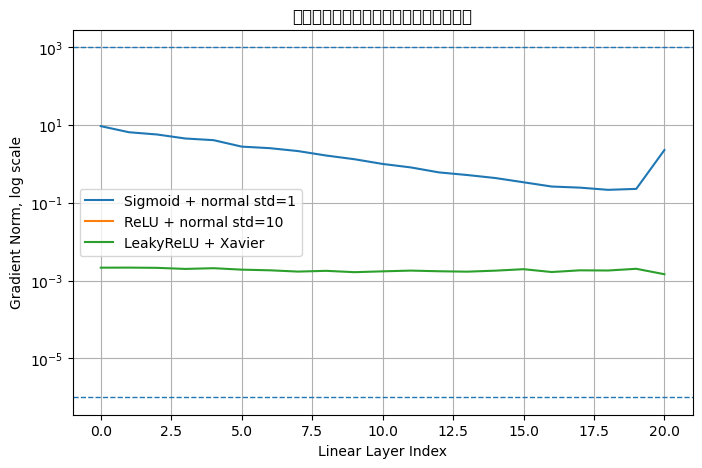

In [9]:
plt.figure(figsize=(8, 5))
plt.semilogy(norms_sigmoid, label='Sigmoid + normal std=1')
plt.semilogy(norms_relu_big, label='ReLU + normal std=10')
plt.semilogy(norms_xavier, label='LeakyReLU + Xavier')
plt.axhline(1e-6, linestyle='--', linewidth=1)
plt.axhline(1e3, linestyle='--', linewidth=1)
plt.xlabel('Linear Layer Index')
plt.ylabel('Gradient Norm, log scale')
plt.title('不同激活函数与初始化策略下的梯度范数')
plt.legend()
plt.grid(True)
plt.show()

## 4. 泛化表现、协变量偏移和对抗性数据

### 4.1 理论计算题

#### 协变量偏移 Covariate Shift

协变量偏移指训练环境与测试环境中的输入分布不同，即：

$$
p(x) \ne q(x)
$$

但给定输入后的标签条件分布不变：

$$
p(y|x)=q(y|x)
$$

例如在医疗诊断中，训练数据主要来自年轻人，部署时主要面对老年人。患者年龄、基础指标等输入特征分布发生变化，但如果同样的检查指标对应同样疾病风险这一机制没有改变，则属于协变量偏移。

#### 标签偏移 Label Shift

标签偏移指训练环境与测试环境中的标签比例不同，即：

$$
p(y) \ne q(y)
$$

但每个类别内部的特征分布不变：

$$
p(x|y)=q(x|y)
$$

例如电商平台中，训练集里正常订单与欺诈订单比例为 99:1，但在某次活动期间欺诈订单比例上升到 95:5。如果欺诈订单本身的特征模式没有变化，只是类别先验比例变化，就属于标签偏移。

#### 区别与联系

二者都属于训练分布与测试分布不一致导致的环境非平稳性问题，都会削弱模型泛化能力。区别在于：协变量偏移主要改变输入 $x$ 的边缘分布，而标签条件机制 $p(y|x)$ 不变；标签偏移主要改变标签 $y$ 的先验分布，而类别条件特征分布 $p(x|y)$ 不变。实际应用中二者可能同时存在，需要根据数据生成机制选择样本重加权、领域自适应或校准等方法。

### 4.2 编程题：模拟协变量偏移并用权重修正改善测试性能

In [10]:
# 人工构造协变量偏移数据集
np.random.seed(seed)

n_train = 1000
n_test = 500

X_train_np = np.random.normal(loc=-1.0, scale=1.0, size=(n_train, 1))
eps_train = np.random.normal(loc=0.0, scale=0.3, size=(n_train, 1))
y_train_np = 2 * X_train_np + eps_train

X_test_np = np.random.normal(loc=2.0, scale=1.0, size=(n_test, 1))
eps_test = np.random.normal(loc=0.0, scale=0.3, size=(n_test, 1))
y_test_np = 2 * X_test_np + eps_test

print('训练集 X 均值:', X_train_np.mean(), '测试集 X 均值:', X_test_np.mean())

训练集 X 均值: -0.9806679441776744 测试集 X 均值: 1.9884836391368992


In [11]:
# 基线线性回归：普通最小二乘
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

base_lr = LinearRegression()
base_lr.fit(X_train_np, y_train_np)
y_pred_base = base_lr.predict(X_test_np)
mse_base = mean_squared_error(y_test_np, y_pred_base)
print('基线模型系数:', base_lr.coef_.ravel(), '截距:', base_lr.intercept_.ravel())
print('校正前测试 MSE:', mse_base)

基线模型系数: [1.9876543] 截距: [0.00914384]
校正前测试 MSE: 0.09164053106289893


In [12]:
# 训练域分类器，估计 P(test|x) 与 P(train|x)
X_domain = np.vstack([X_train_np, X_test_np])
y_domain = np.concatenate([np.zeros(n_train), np.ones(n_test)])

clf = LogisticRegression()
clf.fit(X_domain, y_domain)

prob_train_samples = clf.predict_proba(X_train_np)
p_train = prob_train_samples[:, 0]
p_test = prob_train_samples[:, 1]

# 密度比权重 w_i ∝ P(test|x_i) / P(train|x_i)
weights = p_test / np.clip(p_train, 1e-6, None)
weights = weights / weights.mean()
weights = np.clip(weights, 0, 50)

print('样本权重统计：')
print('min=', weights.min(), 'max=', weights.max(), 'mean=', weights.mean())

样本权重统计：
min= 5.194385636274106e-07 max= 50.0 mean= 0.3800100801263532


In [13]:
# 加权最小二乘线性回归
weighted_lr = LinearRegression()
weighted_lr.fit(X_train_np, y_train_np, sample_weight=weights)
y_pred_weighted = weighted_lr.predict(X_test_np)
mse_weighted = mean_squared_error(y_test_np, y_pred_weighted)

print('加权模型系数:', weighted_lr.coef_.ravel(), '截距:', weighted_lr.intercept_.ravel())
print('校正前测试 MSE:', mse_base)
print('校正后测试 MSE:', mse_weighted)
print('MSE 改变量:', mse_base - mse_weighted)

加权模型系数: [2.11430694] 截距: [-0.13378931]
校正前测试 MSE: 0.09164053106289893
校正后测试 MSE: 0.11214783656301779
MSE 改变量: -0.020507305500118853


f:\anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21327 (\N{CJK UNIFIED IDEOGRAPH-534F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20559 (\N{CJK UNIFIED IDEOGRAPH-504F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31227 (\N{CJK UNIFIED IDEOGRAPH-79FB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\anconda\Lib\site-packa

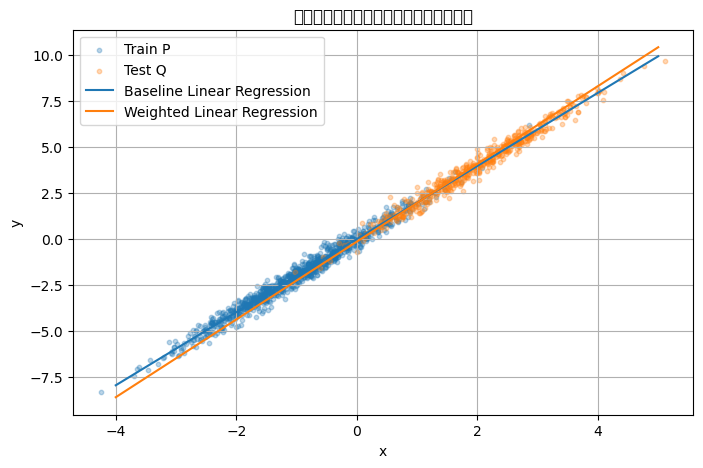

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train_np[:, 0], y_train_np[:, 0], s=10, alpha=0.3, label='Train P')
plt.scatter(X_test_np[:, 0], y_test_np[:, 0], s=10, alpha=0.3, label='Test Q')
xs = np.linspace(-4, 5, 200).reshape(-1, 1)
plt.plot(xs[:, 0], base_lr.predict(xs), label='Baseline Linear Regression')
plt.plot(xs[:, 0], weighted_lr.predict(xs), label='Weighted Linear Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.title('协变量偏移下的基线模型与加权校正模型')
plt.legend()
plt.grid(True)
plt.show()

## 5. 总结

本作业完成了以下内容：

1. 证明无非线性激活函数的多层线性网络等价于单层线性网络。
2. 推导 Sigmoid 与 tanh 的导数形式。
3. 从零实现单隐藏层 MLP、多分类 Softmax 交叉熵与 Mini-batch SGD。
4. 实现权重衰减与 Dropout，并对比三种正则化设置下的 Loss 曲线。
5. 构建深层网络实验，观察 Sigmoid、ReLU 大初始化和 Xavier 初始化对梯度稳定性的影响。
6. 模拟协变量偏移，并通过基于域分类器的样本重加权改善测试集预测性能。